# RSNA Data Exploration

This notebook inspects the two RSNA metadata files and validates the assumptions required by the `PNE-7` ingestion pipeline.

The notebook does **not** generate production metadata. Reusable parsing, validation, and output logic belongs under `src/pneumonai/data/`.

## 1. Load source metadata

The detailed-class file contains one source class per image. The labels file contains the binary target and zero or more bounding boxes per image.

In [48]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pydicom

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
dataset_root = repo_root / "data" / "raw" / "rsna_pneumonia_2018"
source_metadata = dataset_root / "source_metadata"
train_images_dir = dataset_root / "train" / "images"

class_path = source_metadata / "stage_2_detailed_class_info.csv"
labels_path = source_metadata / "stage_2_train_labels.csv"

class_info_raw = pd.read_csv(class_path)
labels_raw = pd.read_csv(labels_path)

print(f"Detailed-class rows: {len(class_info_raw):,}")
print(f"Label rows:          {len(labels_raw):,}")
print(f"Class columns:       {class_info_raw.columns.tolist()}")
print(f"Label columns:       {labels_raw.columns.tolist()}")

Detailed-class rows: 30,227
Label rows:          30,227
Class columns:       ['patientId', 'class']
Label columns:       ['patientId', 'x', 'y', 'width', 'height', 'Target']


In [49]:
display(class_info_raw.head())
display(labels_raw.head())

,patientId,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,No Lung Opacity / Not Normal
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,Normal
4,00436515-870c-4b36-a041-de91049b9ab4,Lung Opacity


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


## 2. Understand the detailed classes

- `Normal`: no significant abnormality was identified.
- `No Lung Opacity / Not Normal`: the image is abnormal, but the target lung opacity was not identified.
- `Lung Opacity`: an opacity suspicious for pneumonia was identified.

For the binary MVP target, the first two classes map to `0` and `Lung Opacity` maps to `1`. The original class is preserved as `raw_class`; label `0` must not be described as healthy or normal.

,row_count
class,
No Lung Opacity / Not Normal,11821
Lung Opacity,9555
Normal,8851


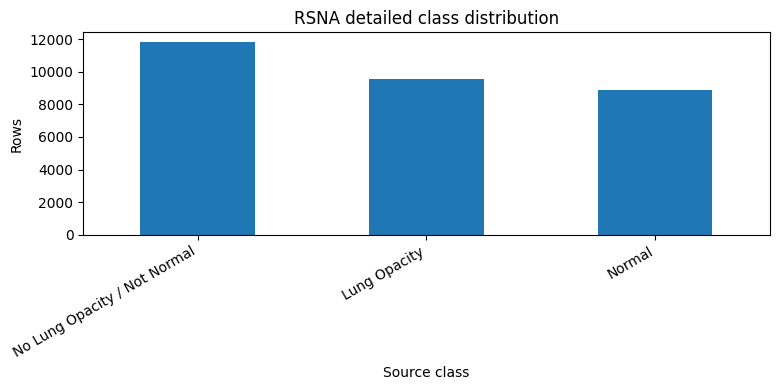

In [50]:
class_distribution = class_info_raw["class"].value_counts()
display(class_distribution.rename("row_count").to_frame())

ax = class_distribution.plot(kind="bar", figsize=(8, 4), title="RSNA detailed class distribution")
ax.set_xlabel("Source class")
ax.set_ylabel("Rows")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 3. Validate and map detailed classes

Repeated rows are acceptable only when they repeat the same class for the same image. A patient ID with multiple different classes is a conflict and must be rejected by production ingestion.

In [51]:
expected_classes = {
    "Normal",
    "No Lung Opacity / Not Normal",
    "Lung Opacity",
}
observed_classes = set(class_info_raw["class"].dropna().unique())
unsupported_classes = observed_classes - expected_classes

class_counts_per_image = class_info_raw.groupby("patientId")["class"].nunique()
class_conflicts = class_counts_per_image[class_counts_per_image > 1]
duplicate_class_rows = class_info_raw.duplicated(["patientId", "class"], keep=False)

print(f"Unique image IDs:       {class_info_raw['patientId'].nunique():,}")
print(f"Repeated source rows:   {int(duplicate_class_rows.sum()):,}")
print(f"Conflicting image IDs:  {len(class_conflicts):,}")
print(f"Unsupported classes:    {sorted(unsupported_classes)}")

assert not unsupported_classes, f"Unsupported classes: {unsupported_classes}"
assert class_conflicts.empty, "Some image IDs have conflicting detailed classes"

class_info = class_info_raw.drop_duplicates(["patientId", "class"]).copy()
label_mapping = {
    "Normal": 0,
    "No Lung Opacity / Not Normal": 0,
    "Lung Opacity": 1,
}
class_info = class_info.rename(columns={"class": "raw_class"})
class_info["class_label"] = class_info["raw_class"].map(label_mapping)

assert class_info["class_label"].notna().all()
assert class_info["patientId"].is_unique
display(class_info.head())

Unique image IDs:       26,684
Repeated source rows:   6,941
Conflicting image IDs:  0
Unsupported classes:    []


,patientId,raw_class,class_label
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,No Lung Opacity / Not Normal,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,No Lung Opacity / Not Normal,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,No Lung Opacity / Not Normal,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,Normal,0
4,00436515-870c-4b36-a041-de91049b9ab4,Lung Opacity,1


## 4. Validate target and bounding-box rows

A negative row (`Target = 0`) must have no box coordinates. A positive row (`Target = 1`) must have all four box values. Every image must have one consistent target.

In [52]:
box_columns = ["x", "y", "width", "height"]
observed_targets = set(labels_raw["Target"].dropna().unique())

invalid_negative = labels_raw[
    labels_raw["Target"].eq(0)
    & labels_raw[box_columns].notna().any(axis=1)
]
invalid_positive = labels_raw[
    labels_raw["Target"].eq(1)
    & labels_raw[box_columns].isna().any(axis=1)
]
target_counts_per_image = labels_raw.groupby("patientId")["Target"].nunique()
target_conflicts = target_counts_per_image[target_counts_per_image > 1]

print(f"Observed targets:             {sorted(observed_targets)}")
print(f"Invalid negative rows:        {len(invalid_negative):,}")
print(f"Incomplete positive rows:     {len(invalid_positive):,}")
print(f"Conflicting target image IDs: {len(target_conflicts):,}")

assert observed_targets <= {0, 1}
assert invalid_negative.empty
assert invalid_positive.empty
assert target_conflicts.empty

Observed targets:             [np.int64(0), np.int64(1)]
Invalid negative rows:        0
Incomplete positive rows:     0
Conflicting target image IDs: 0


## 5. Separate image targets from localization boxes

The image table must contain one row per image. The box table may contain several rows for one positive image. Exactly duplicated box rows contain no additional location information, so production ingestion should keep one and report how many were removed.

In [53]:
image_targets = (
    labels_raw[["patientId", "Target"]]
    .drop_duplicates()
    .rename(columns={"Target": "label"})
    .reset_index(drop=True)
)

boxes_raw = labels_raw.loc[
    labels_raw["Target"].eq(1),
    ["patientId", *box_columns],
].copy()

exact_duplicate_boxes = boxes_raw.duplicated(
    ["patientId", *box_columns], keep=False
)
boxes = boxes_raw.drop_duplicates(["patientId", *box_columns]).reset_index(drop=True)

invalid_geometry = boxes[
    boxes["x"].lt(0)
    | boxes["y"].lt(0)
    | boxes["width"].le(0)
    | boxes["height"].le(0)
]

boxes_per_image = boxes.groupby("patientId").size()

print(f"Image-level target rows:       {len(image_targets):,}")
print(f"Raw positive box rows:         {len(boxes_raw):,}")
print(f"Unique box rows:               {len(boxes):,}")
print(f"Rows participating in an exact duplicate: {int(exact_duplicate_boxes.sum()):,}")
print(f"Invalid geometry rows:         {len(invalid_geometry):,}")
print(f"Maximum boxes on one image:    {int(boxes_per_image.max())}")

assert image_targets["patientId"].is_unique
assert invalid_geometry.empty
display(boxes_per_image.value_counts().sort_index().rename("image_count").to_frame())

Image-level target rows:       26,684
Raw positive box rows:         9,555
Unique box rows:               9,555
Rows participating in an exact duplicate: 0
Invalid geometry rows:         0
Maximum boxes on one image:    4


,image_count
1,2614
2,3266
3,119
4,13


## 6. Check agreement between both source files

The binary target from the labels file must agree with the binary mapping derived from the detailed class file. The source class remains available for future subgroup evaluation.

In [54]:
image_metadata = image_targets.merge(
    class_info,
    on="patientId",
    how="outer",
    validate="one_to_one",
    indicator=True,
)

missing_from_either_source = image_metadata[image_metadata["_merge"].ne("both")]
label_disagreements = image_metadata[
    image_metadata["_merge"].eq("both")
    & image_metadata["label"].ne(image_metadata["class_label"])
]

print(f"Merged image IDs:             {len(image_metadata):,}")
print(f"Missing from one source:      {len(missing_from_either_source):,}")
print(f"Binary-label disagreements:   {len(label_disagreements):,}")

assert missing_from_either_source.empty
assert label_disagreements.empty

image_metadata = image_metadata.drop(columns=["class_label", "_merge"])
display(pd.crosstab(image_metadata["raw_class"], image_metadata["label"], margins=True))
display(image_metadata.head())

Merged image IDs:             26,684
Missing from one source:      0
Binary-label disagreements:   0


label,0,1,All
raw_class,,,
Lung Opacity,0,6012,6012
No Lung Opacity / Not Normal,11821,0,11821
Normal,8851,0,8851
All,20672,6012,26684


,patientId,label,raw_class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0,No Lung Opacity / Not Normal
1,000924cf-0f8d-42bd-9158-1af53881a557,0,Normal
2,000db696-cf54-4385-b10b-6b16fbb3f985,1,Lung Opacity
3,000fe35a-2649-43d4-b027-e67796d412e0,1,Lung Opacity
4,001031d9-f904-4a23-b3e5-2c088acd19c6,1,Lung Opacity


## 7. Verify DICOM file coverage

Every labeled image ID must resolve to one local training DICOM. Extra files and missing files must be reported rather than silently ignored.

In [55]:
expected_image_ids = set(image_metadata["patientId"])
available_image_ids = {path.stem for path in train_images_dir.glob("*.dcm")}

missing_dicom_ids = sorted(expected_image_ids - available_image_ids)
extra_dicom_ids = sorted(available_image_ids - expected_image_ids)

print(f"Expected labeled images: {len(expected_image_ids):,}")
print(f"Available DICOM images:  {len(available_image_ids):,}")
print(f"Missing DICOM files:     {len(missing_dicom_ids):,}")
print(f"Extra DICOM files:       {len(extra_dicom_ids):,}")

assert not missing_dicom_ids
assert not extra_dicom_ids

Expected labeled images: 26,684
Available DICOM images:  26,684
Missing DICOM files:     0
Extra DICOM files:       0


## 8. Inspect representative DICOM images

This small sample verifies that files can be decoded and that bounding boxes use the original image coordinate system. Full-file readability validation belongs in the production ingestion pipeline.

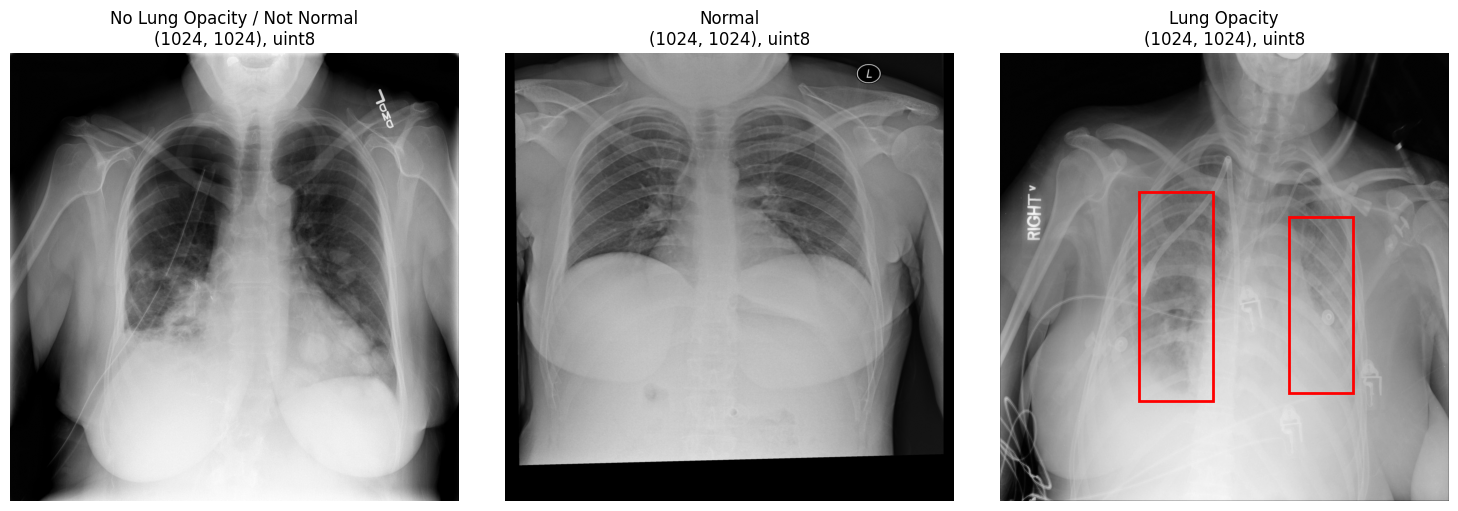

In [56]:
sample_ids = (
    image_metadata.groupby("raw_class", group_keys=False)
    .head(1)["patientId"]
    .tolist()
)

fig, axes = plt.subplots(1, len(sample_ids), figsize=(15, 5))
if len(sample_ids) == 1:
    axes = [axes]

for ax, patient_id in zip(axes, sample_ids):
    dicom_path = train_images_dir / f"{patient_id}.dcm"
    dataset = pydicom.dcmread(dicom_path)
    pixels = dataset.pixel_array
    raw_class = image_metadata.loc[
        image_metadata["patientId"].eq(patient_id), "raw_class"
    ].iloc[0]

    ax.imshow(pixels, cmap="gray")
    for box in boxes.loc[boxes["patientId"].eq(patient_id)].itertuples():
        rectangle = plt.Rectangle(
            (box.x, box.y),
            box.width,
            box.height,
            fill=False,
            edgecolor="red",
            linewidth=2,
        )
        ax.add_patch(rectangle)

    ax.set_title(f"{raw_class}\n{pixels.shape}, {pixels.dtype}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 9. Exploration conclusions

After all assertions pass, record the observed counts here before implementing `PNE-7`:

- The detailed classes are mapped to a binary **target opacity absent/present** label while preserving `raw_class`.
- There is exactly one image-level target per image.
- Positive images may have multiple bounding boxes.
- Negative rows have no bounding boxes.
- Both source files agree on the binary target.
- Every labeled image has a corresponding local DICOM file.

The production ingestion pipeline must repeat these validations, generate canonical `images.csv` and `bounding_boxes.csv`, and report any rejected records.